In [39]:
from src.utils import read_data, get_events, segment_events
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import json
import pandas as pd

#import json config file
with open('config.json', 'r') as f:
    config = json.load(f)

min_lon = config['min_lon']
max_lon = config['max_lon']
min_lat = config['min_lat']
max_lat = config['max_lat']

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_time_series(year, month, day, i, j, with_events=False):
    raw_data = read_data(year, month, day)  # Ensure month and day are in correct order
    ts = raw_data[:, i, j]
    events = segment_events(ts)

    # Generate a time array that represents each time point in hours from 0 to 24
    time = np.linspace(0, 24, num=len(ts), endpoint=False)

    plt.figure(figsize=(12, 6))
    plt.plot(time, ts, label='Time Series')  # Use 'time' as x-axis data

    # Highlight each event with a shaded area
    if with_events:
        for start, end in events:
            plt.axvspan(time[start], time[end], color='yellow', alpha=0.3)

    # Setting up x-axis ticks to appear every 30 minutes with formatted labels
    half_hour_ticks = np.arange(0, 24 + 1, 1)  # Create ticks every 0.5 hours
    half_hour_labels = [f"{int(tick):02d}:{int((tick % 1) * 60):02d}" for tick in half_hour_ticks]  # Format as HH:MM
    plt.xticks(half_hour_ticks, half_hour_labels, fontsize=8)  # Set x-ticks every 30 minutes with smaller font size

    # Adding labels and title for clarity
    plt.xlabel('Temps')
    plt.ylabel('Pluie (mm)')
    plt.title(f'Evénements de pluie le {day}/{month}/{year} en ({i}, {j})')
    plt.grid(True)
    plt.show()


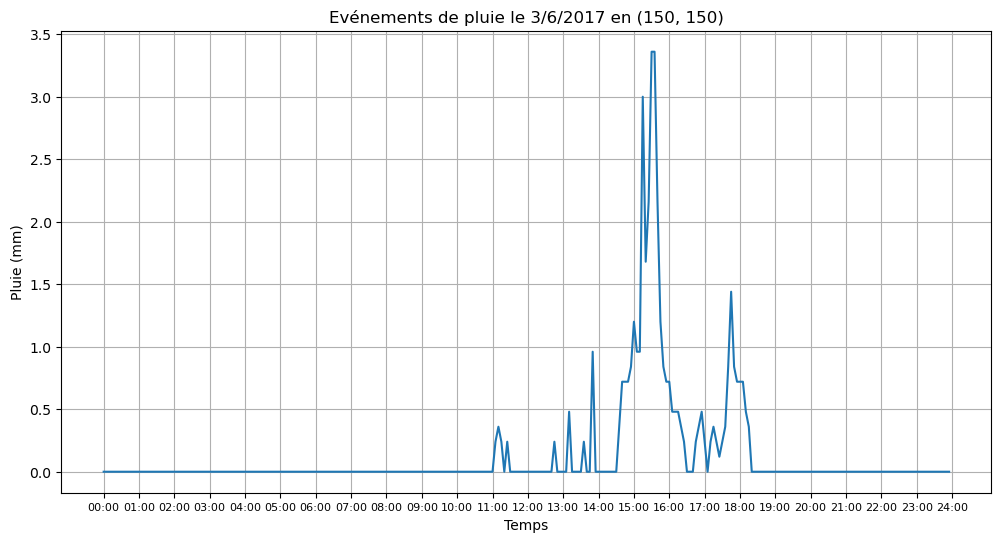

In [3]:
plot_time_series(2017, 6, 3, 150, 150)

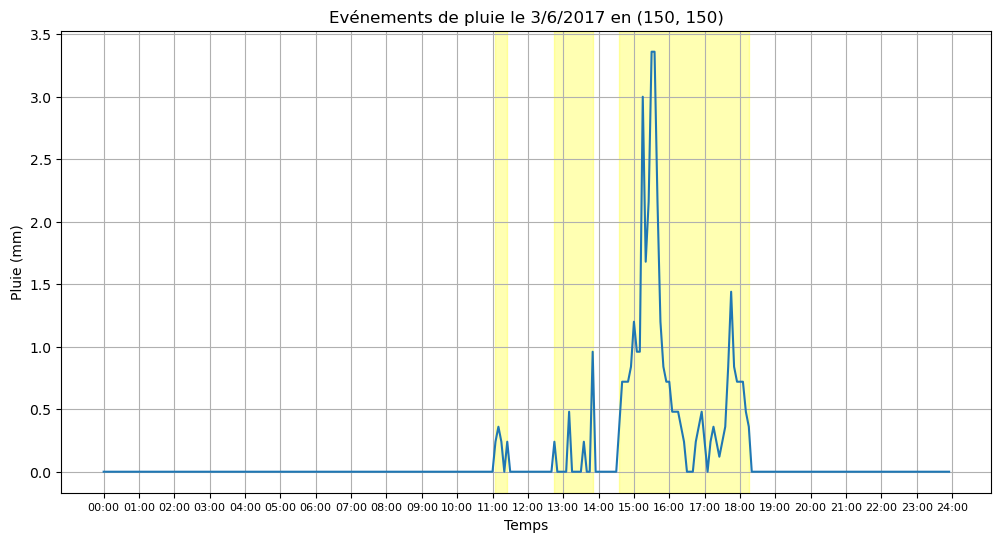

In [4]:
plot_time_series(2017, 6, 3, 150, 150, with_events=True)

In [19]:
tmp = np.load('positionPixelsIDF300x300.npz')

lat=tmp['lat']

lon = tmp['lon']


In [21]:
lat.shape

(300, 300)

In [8]:
pix159_147 = (lat[159,147], lon[159,147])
pix159_147

(48.85855898794706, 2.2094434733492605)

In [24]:
import geopandas as gpd

In [33]:
pix0_0 = (lat[0,0], lon[0,0])
pix0_299 = (lat[0,299], lon[0,299])
pix299_0 = (lat[299,0], lon[299,0])
pix299_299 = (lat[299,299], lon[299,299])

min_lon = min(pix0_0[1], pix0_299[1], pix299_0[1], pix299_299[1])
max_lon = max(pix0_0[1], pix0_299[1], pix299_0[1], pix299_299[1])
min_lat = min(pix0_0[0], pix0_299[0], pix299_0[0], pix299_299[0])
max_lat = max(pix0_0[0], pix0_299[0], pix299_0[0], pix299_299[0])


In [35]:
# save min_lon, max_lon, min_lat, max_lat to a config file


config = {
    'min_lon': min_lon,
    'max_lon': max_lon,
    'min_lat': min_lat,
    'max_lat': max_lat
}

with open('config.json', 'w') as f:
    json.dump(config, f)
    


In [7]:
import geopandas as gpd
import geodatasets
import shapely.speedups

shapely.speedups.enable()

C:\Users\Benjamin\AppData\Local\Temp\ipykernel_19056\2769445487.py:5: DeprecationWarning: This function has no longer any effect, and will be removed in a future release. Starting with Shapely 2.0, equivalent speedups are always available
  shapely.speedups.enable()


In [4]:
def plot_boundaries(ax, color='grey', linewidth=0.3):
    gdf = gpd.read_file('departements.geojson')
    gdf.boundary.plot(ax=ax, edgecolor=color, linewidth=linewidth, facecolor='none')

In [31]:
def plot_monthly_precipitation(year, month):
    """Plot monthly cumulative precipitation for a specific year and month."""
    fig, ax = plt.subplots()
    plot_boundaries(ax, color="white")
    data = []
    for day in range(1, 32):
        try:
            daily_data = read_data(year, month, day)
            if daily_data is not None:
                daily_sum = np.nan_to_num(np.sum(daily_data, axis=0))
                data.append(daily_sum)
        except FileNotFoundError:
            continue
    
    if data:
        cumulative_precipitation = np.sum(data, axis=0)
        im = ax.imshow(cumulative_precipitation, cmap='plasma', extent=[min_lon, max_lon, min_lat, max_lat], aspect='auto', vmin=0, vmax=7000) #hardcoded for now
        ax.set_title(f'Cumul de pluie pour {year}-{month:02d}')
        ax.axis('off')
        fig.colorbar(im, ax=ax, label='Précipitations (mm)')
        plt.show()
    else:
        print(f"No data available for {year}-{month:02d}.")

def plot_monthly_precipitation_grid(year):
    """Plot cumulative precipitation for each month of a year."""
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    for month in range(1, 13):
        plot_monthly_precipitation(year, month)
    
    plt.suptitle(f'Cumul de pluie mensuels pour {year}')
    plt.tight_layout(rect=[0, 0, 0.9, 0.93])
    plt.show()

def plot_yearly_precipitation(year):
    """Plot yearly cumulative precipitation for a specific year."""
    fig, ax = plt.subplots()
    plot_boundaries(ax, color="white")  # Assuming this function sets up the plot boundaries
    yearly_data = []

    for month in range(1, 13):
        monthly_data = []
        for day in range(1, 32):
            try:
                daily_data = read_data(year, month, day)
                if daily_data is not None:
                    daily_sum = np.nan_to_num(np.sum(daily_data, axis=0))
                    monthly_data.append(daily_sum)
            except FileNotFoundError:
                continue
        
        if monthly_data:
            # Sum over all days of the month and append to yearly data
            monthly_cumulative = np.sum(monthly_data, axis=0)
            yearly_data.append(monthly_cumulative)

    if yearly_data:
        cumulative_precipitation = np.sum(yearly_data, axis=0)
        im = ax.imshow(cumulative_precipitation, cmap='plasma', extent=[min_lon, max_lon, min_lat, max_lat], aspect='auto')
        ax.set_title(f'Cumul de pluie pour {year}')
        ax.axis('off')
        fig.colorbar(im, ax=ax, label='Precipitations (mm)')
        plt.show()
    else:
        print(f"No data available for {year}.")



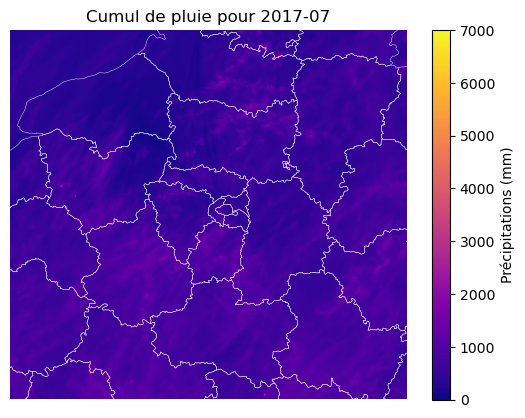

In [32]:
plot_monthly_precipitation(2017, 7)

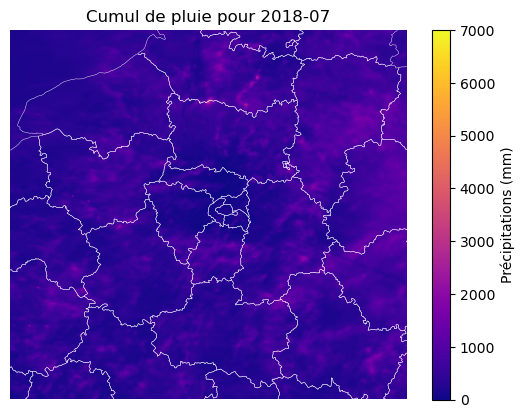

In [33]:
plot_monthly_precipitation(2018, 7)

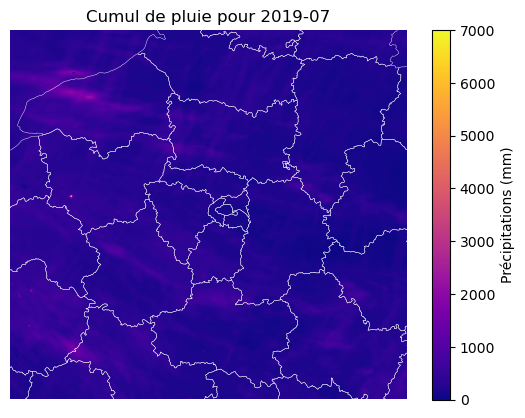

In [34]:
plot_monthly_precipitation(2019, 7)


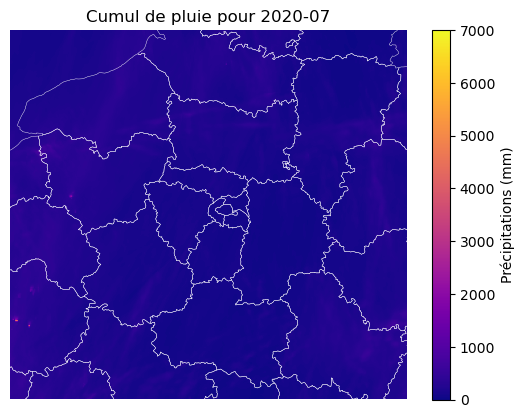

In [35]:
plot_monthly_precipitation(2020, 7)


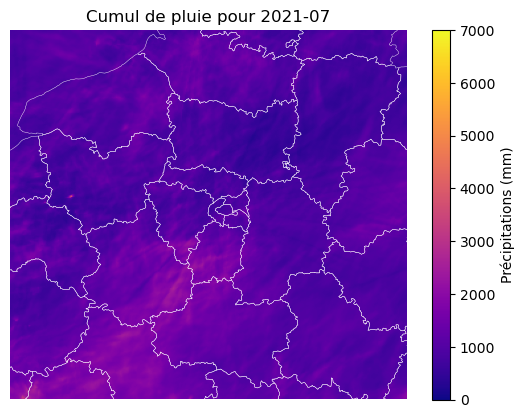

In [36]:
plot_monthly_precipitation(2021, 7)


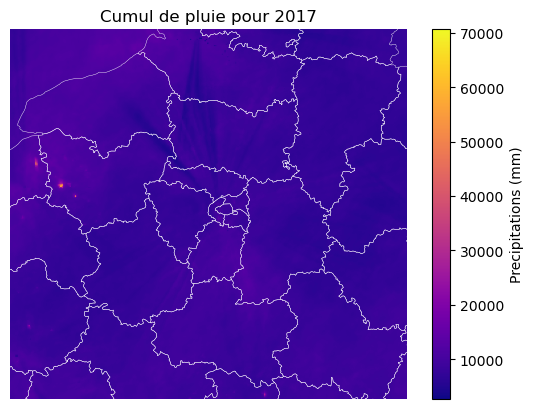

In [27]:
plot_yearly_precipitation(2017)

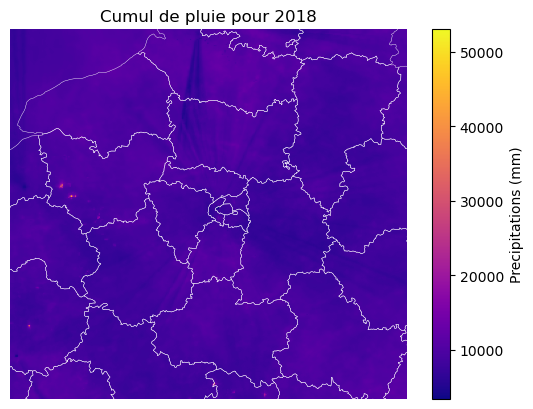

In [95]:
plot_yearly_precipitation(2018)

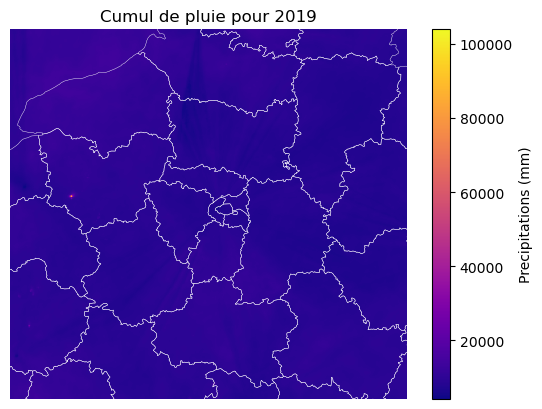

In [28]:
plot_yearly_precipitation(2019)

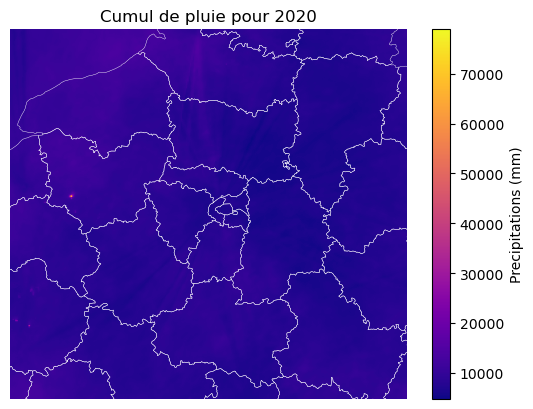

In [29]:
plot_yearly_precipitation(2020)

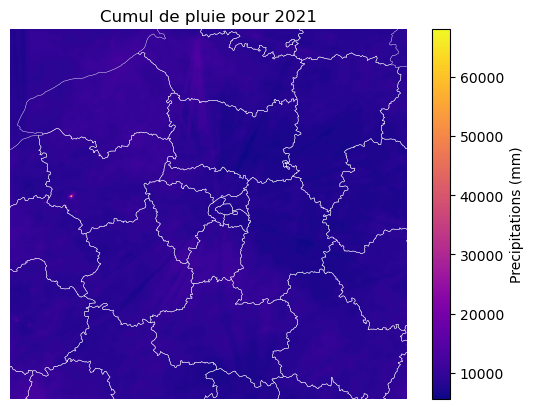

In [30]:
plot_yearly_precipitation(2021)

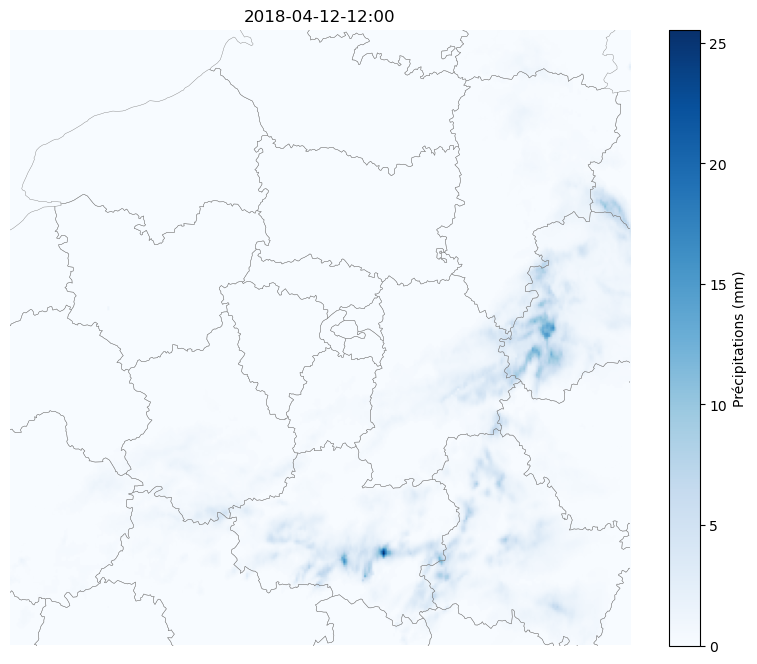

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rain_data_at_time(year: int, month: int, day: int, time_index: int):
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_boundaries(ax)
    try:
        raw_data = read_data(year, month, day)
        if time_index < 0 or time_index >= raw_data.shape[0]:
            raise ValueError(f"Time index {time_index} is out of the valid range (0-287).")
        
        grid_data = raw_data[time_index, :, :]
        
        im = ax.imshow(grid_data, cmap='Blues', extent=[min_lon, max_lon, min_lat, max_lat], aspect='auto')
        ax.set_title(f'{year}-{month:02d}-{day}-{time_index // 12:02d}:{(time_index % 12) * 5:02d}')
        ax.axis('off')
        ax.set_xlim([min_lon, max_lon])
        ax.set_ylim([min_lat, max_lat])
        fig.colorbar(im, ax=ax, label='Précipitations (mm)')
        plt.show()
    except FileNotFoundError as e:
        print(e)
    except ValueError as e:
        print(e)

# Example usage
plot_rain_data_at_time(2018, 4, 12, 144)  # Replace 2023, 4, 12, 150 with actual parameters


In [17]:
import imageio
import os

def create_gif_from_pngs(folder_path, output_filename='output.gif', duration=0.5, loop=0):
    # Create a list of file paths
    image_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.png')]
    # Sort the files to maintain order
    image_files.sort()

    # List to hold images
    images = []
    for file in image_files:
        images.append(imageio.imread(file))

    # Create GIF
    output_gif_path = os.path.join(folder_path, output_filename)
    imageio.mimsave(output_gif_path, images, duration=duration, loop=loop)
    return f'GIF created at {output_gif_path}'


In [20]:
import os
import matplotlib.pyplot as plt

def plot_rain_data_for_day(year: int, month: int, day: int):
    try:
        raw_data = read_data(year, month, day)
        folder_path = f'{year}-{month:02d}-{day:02d}'
        output_filename = f'{year}-{month:02d}-{day:02d}.gif'
        os.makedirs(folder_path, exist_ok=True)
        
        # Define the fixed range for the color scale
        vmin = raw_data.min()  # minimum value for colorbar
        vmax = raw_data.max()  # maximum value for colorbar

        for time_index in range(raw_data.shape[0]):
            fig, ax = plt.subplots(figsize=(10, 8))
            plot_boundaries(ax, color='white')
            grid_data = raw_data[time_index, :, :]
            im = ax.imshow(grid_data, cmap='plasma', extent=[min_lon, max_lon, min_lat, max_lat],
                           aspect='auto', vmin=vmin, vmax=vmax)  # Set the fixed range here
            ax.set_title(f'{year}-{month:02d}-{day}-{time_index // 12:02d}:{(time_index % 12) * 5:02d}')
            ax.axis('off')
            ax.set_xlim([min_lon, max_lon])
            ax.set_ylim([min_lat, max_lat])
            fig.colorbar(im, ax=ax, label='Précipitations (mm)')
            plt.savefig(f'{folder_path}/{time_index:03d}.png')
            plt.close()
        
        create_gif_from_pngs(folder_path, output_filename=output_filename)
    except FileNotFoundError as e:
        print(e)

# Example usage
plot_rain_data_for_day(2020, 5, 2)  # Replace 2023, 4, 12 with actual parameters


C:\Users\Benjamin\AppData\Local\Temp\ipykernel_19056\3133254948.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file))


In [40]:
# open all pickle files into a dataframe
def open_all_pickle_files():
    path = "C:/Users/Benjamin/Documents/Code/precipitations/data/dataframes"
    files = os.listdir(path)
    df = pd.DataFrame()
    i = 0
    for f in files:
        print(f)
        if f.endswith("_8.pkl"):
            df = pd.concat([df, pd.read_pickle(path + "/" + f)])
    return df

df = open_all_pickle_files()

2017.zip
2017_1.pkl
2017_10.pkl
2017_11.pkl
2017_12.pkl
2017_2.pkl
2017_3.pkl
2017_4.pkl
2017_5.pkl
2017_6.pkl
2017_7.pkl
2017_8.pkl
2017_9.pkl
2018.zip
2018_1.pkl
2018_10.pkl
2018_11.pkl
2018_12.pkl
2018_2.pkl
2018_3.pkl
2018_4.pkl
2018_5.pkl
2018_6.pkl
2018_7.pkl
2018_8.pkl
2018_9.pkl
2019.zip
2019_1.pkl
2019_10.pkl
2019_11.pkl
2019_12.pkl
2019_2.pkl
2019_3.pkl
2019_4.pkl
2019_5.pkl
2019_6.pkl
2019_7.pkl
2019_8.pkl
2019_9.pkl
2020.zip
2020_1.pkl
2020_10.pkl
2020_11.pkl
2020_12.pkl
2020_2.pkl
2020_3.pkl
2020_4.pkl
2020_5.pkl
2020_6.pkl
2020_7.pkl
2020_8.pkl
2020_9.pkl
2021.zip
2021_1.pkl
2021_10.pkl
2021_11.pkl
2021_12.pkl
2021_2.pkl
2021_3.pkl
2021_4.pkl
2021_5.pkl
2021_6.pkl
2021_7.pkl
2021_8.pkl
2021_9.pkl


In [41]:
FEATURES = ['duration', 'max_intensity', 'mean_intensity', 'variance', 'percentage_null']
pd.set_option('display.float_format', lambda x: '%.5f' % x)


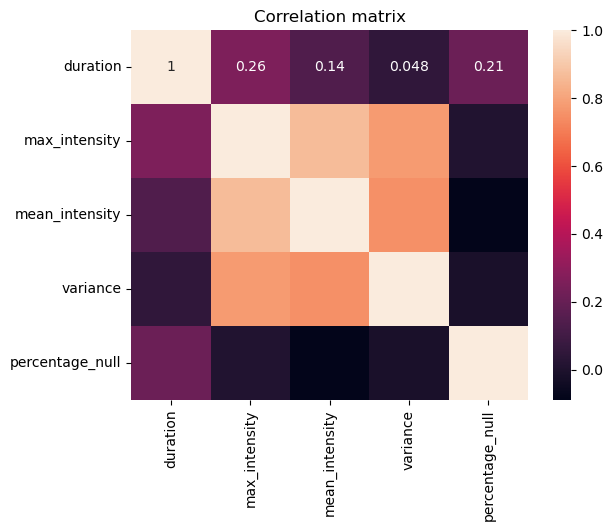

In [43]:
import seaborn as sns 
correlation_matrix = df[FEATURES].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation matrix')
plt.show()

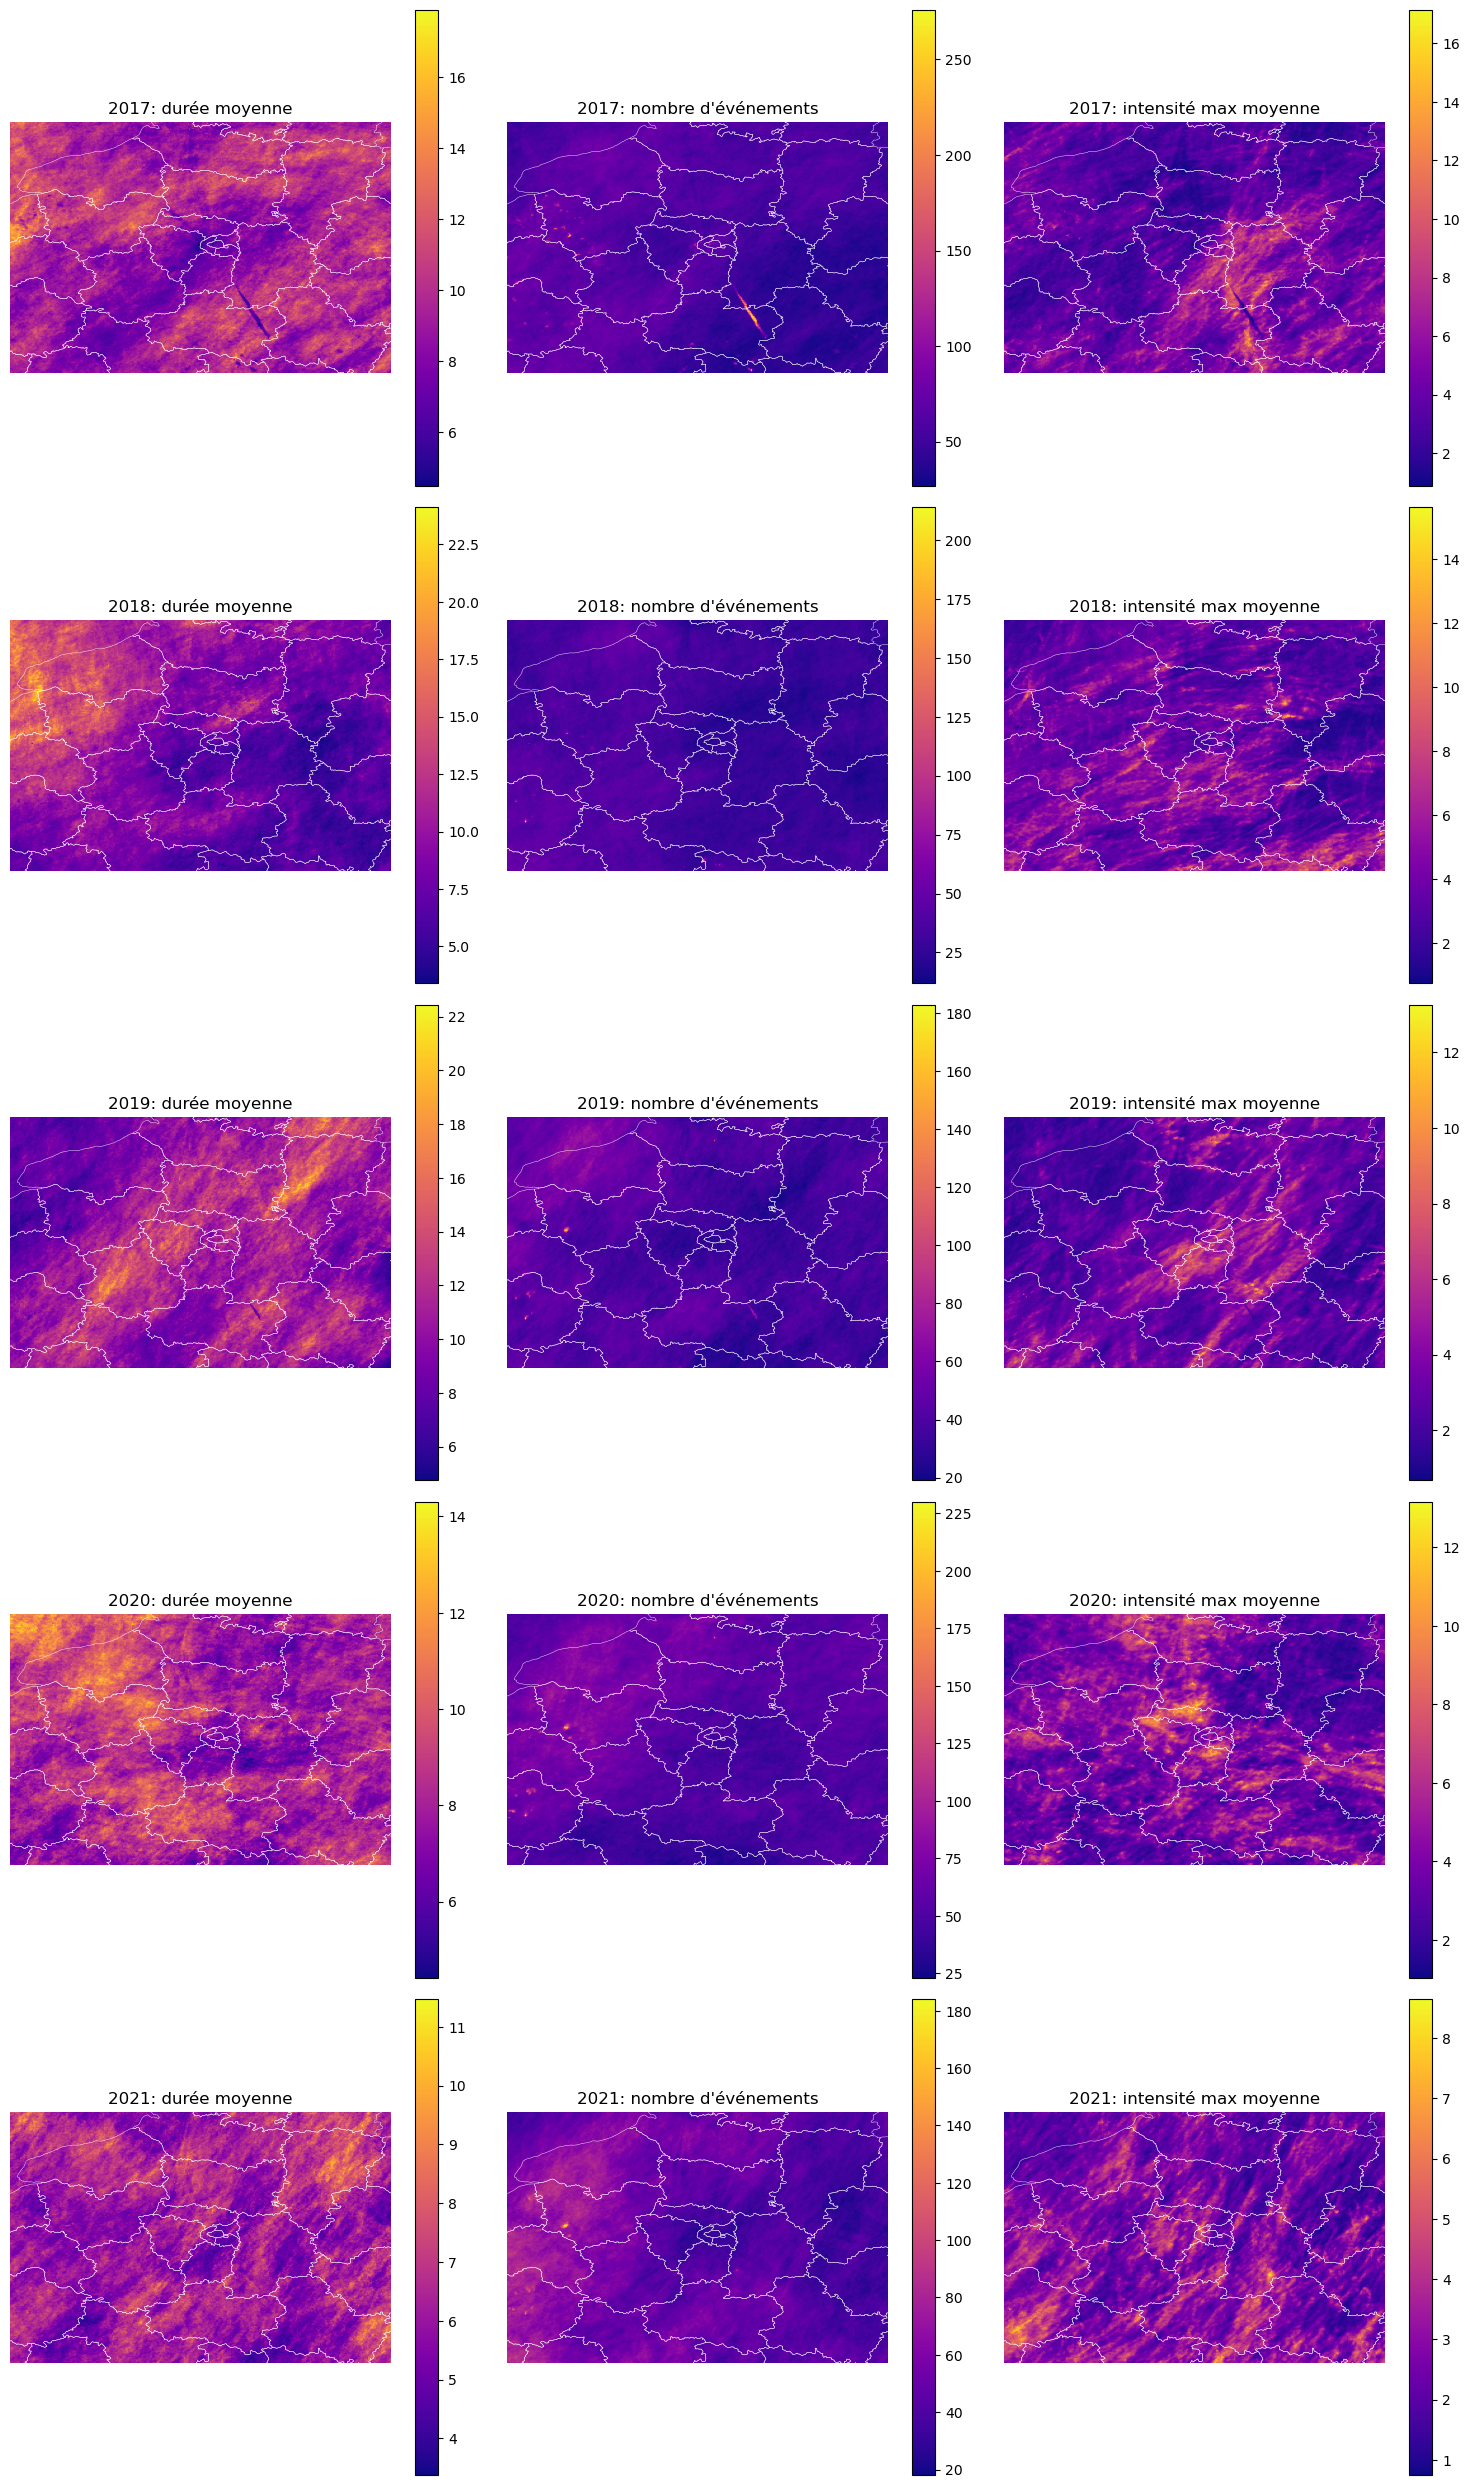

In [45]:
result = df.groupby(['year', 'i', 'j']).agg({'duration': ['mean', 'count'], 'max_intensity': 'mean'}).reset_index()

result.columns = ['year', 'i', 'j', 'mean_duration', 'nb_events', 'mean_max_intensity']

months = result['year'].unique()

fig, axes = plt.subplots(len(months), 3, figsize=(15, 5*len(months)))

for idx, month in enumerate(months):
    month_data = result[result['year'] == month]

    mean_duration_grid = np.zeros((300, 300))
    mean_max_intensity_grid = np.zeros((300, 300))
    count_grid = np.zeros((300, 300))

    for _, row in month_data.iterrows():
        mean_duration_grid[int(row['i']), int(row['j'])] = row['mean_duration']
        mean_max_intensity_grid[int(row['i']), int(row['j'])] = row['mean_max_intensity']
        count_grid[int(row['i']), int(row['j'])] = row['nb_events']

    plot_boundaries(axes[idx, 0], color='white')
    im1 = axes[idx, 0].imshow(mean_duration_grid, cmap='plasma', extent=[min_lon, max_lon, min_lat, max_lat])
    axes[idx, 0].set_title(f'{month}: durée moyenne')
    axes[idx, 0].axis('off')
    cbar1 = fig.colorbar(im1, ax=axes[idx, 0])

    plot_boundaries(axes[idx, 1], color='white')
    im2 = axes[idx, 1].imshow(count_grid, cmap='plasma',extent=[min_lon, max_lon, min_lat, max_lat])
    axes[idx, 1].set_title(f'{month}: nombre d\'événements')
    axes[idx, 1].axis('off')
    cbar2 = fig.colorbar(im2, ax=axes[idx, 1])

    plot_boundaries(axes[idx, 2], color='white')
    im3 = axes[idx, 2].imshow(mean_max_intensity_grid, cmap='plasma',extent=[min_lon, max_lon, min_lat, max_lat])
    axes[idx, 2].set_title(f'{month}: intensité max moyenne')
    axes[idx, 2].axis('off')
    cbar3 = fig.colorbar(im3, ax=axes[idx, 2])

plt.tight_layout()

plt.show()

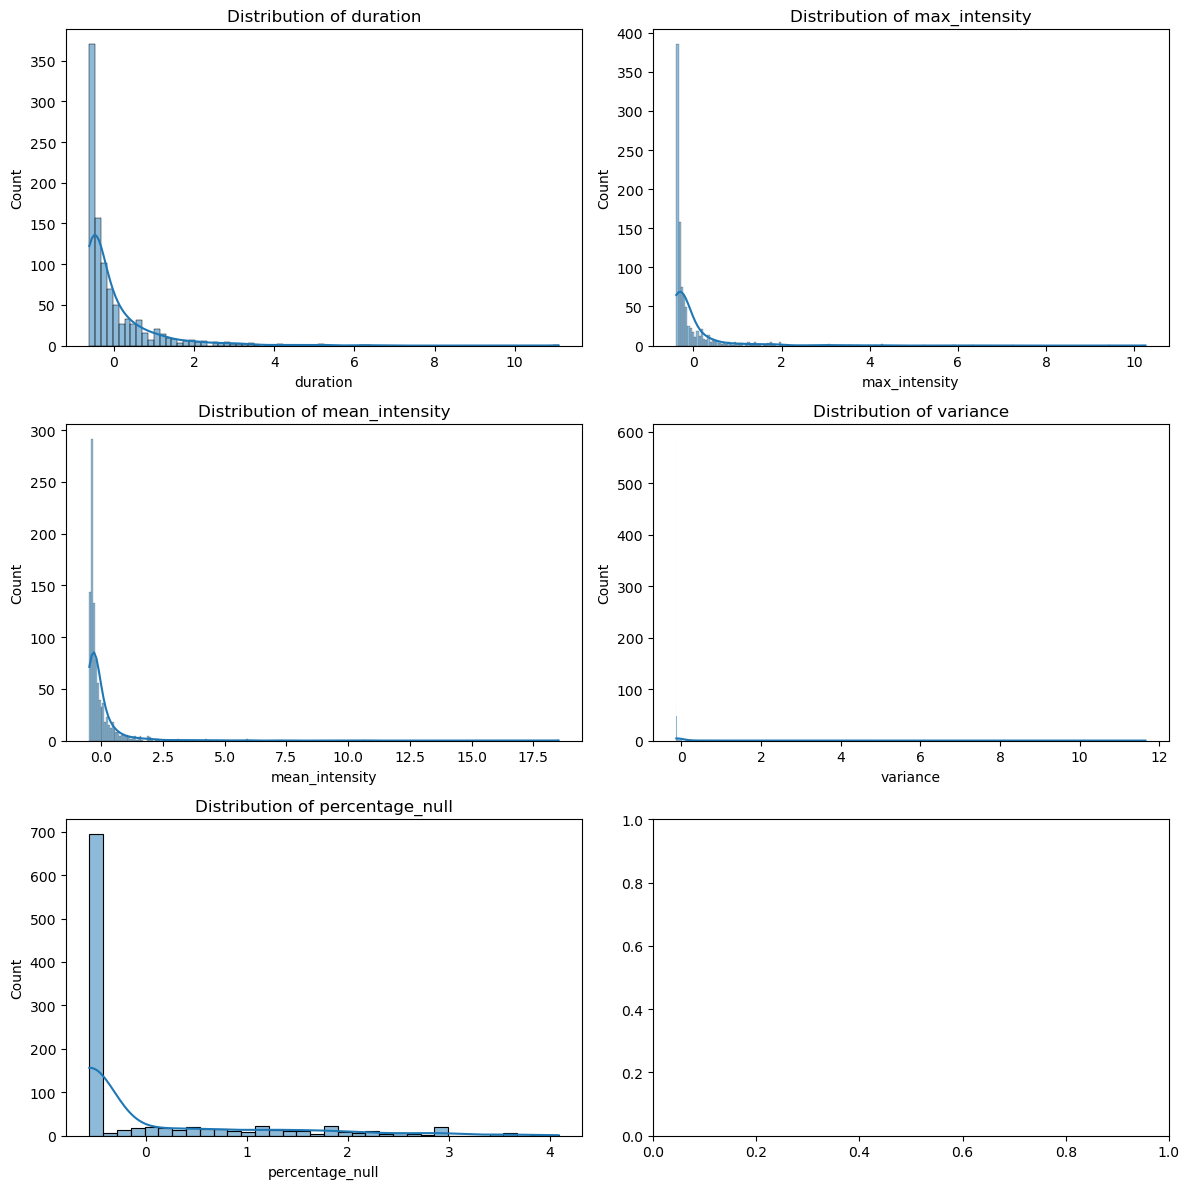

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[FEATURES]), columns=FEATURES)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

df_sample = df_scaled.sample(1000)

for i, feature in enumerate(FEATURES):
    sns.histplot(df_sample[feature], ax=axes[i//2, i%2], kde=True)
    axes[i//2, i%2].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()